## Part A — fixed antigen, per peptide
Neural autoencoder pose tower (seq · pose-only · seq+pose, 6D vs quaternion-NN) **and** FramePose-only **tree ensembles** (RF / ExtraTrees / HistGBT on reach+direction+6D-rotation features), all on the same 10× repeated leakage-controlled 80/20 splits. Bootstrap contrasts: does pose help (seq+pose_6d − seq), 6d vs qnn, and **autoencoder vs tree** (pose_only_6d − FramePose_ExtraTrees).

In [1]:
import torch
print("torch",torch.__version__,"| CUDA:",torch.cuda.is_available())
device=torch.device("cuda" if torch.cuda.is_available() else "cpu"); print("device:",device)

torch 2.11.0+cu128 | CUDA: True
device: cuda


## Mount Google Drive
Put `combined_sorted.csv`, `pose_descriptors.csv`, `iptm_table.csv` in your `DATA_DIR`; all tables/figures are written to `OUT_DIR`.

In [2]:
from google.colab import drive
import os
drive.mount('/content/drive')
# EDIT these to your Drive locations:
DATA_DIR = "/content/drive/MyDrive"          # folder with the 3 input CSVs
OUT_DIR  = "/content/drive/MyDrive/tcrpmhc_outputs"  # where tables/figures are written
os.makedirs(OUT_DIR, exist_ok=True)
print("inputs from:", DATA_DIR, "\noutputs to: ", OUT_DIR)

Mounted at /content/drive
inputs from: /content/drive/MyDrive 
outputs to:  /content/drive/MyDrive/tcrpmhc_outputs


In [3]:
import re, math
import numpy as np, pandas as pd
import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score
np.random.seed(42); torch.manual_seed(42)

## Encoding: Atchley (TCR chains + peptide) + CDR3/V extraction

In [4]:
ATCHLEY={'A':(-0.591,-1.302,-0.733,1.570,-0.146),'C':(-1.343,0.465,-0.862,-1.020,-0.255),
 'D':(1.050,0.302,-3.656,-0.259,-3.242),'E':(1.357,-1.453,1.477,0.113,-0.837),
 'F':(-1.006,-0.590,1.891,-0.397,0.412),'G':(-0.384,1.652,1.330,1.045,2.064),
 'H':(0.336,-0.417,-1.673,-1.474,-0.078),'I':(-1.239,-0.547,2.131,0.393,0.816),
 'K':(1.831,-0.561,0.533,-0.277,1.648),'L':(-1.019,-0.987,-1.505,1.266,-0.912),
 'M':(-0.663,-1.524,2.219,-1.005,1.212),'N':(0.945,0.828,1.299,-0.169,0.933),
 'P':(0.189,2.081,-1.628,0.421,-1.392),'Q':(0.931,-0.179,-3.005,-0.503,-1.853),
 'R':(1.538,-0.055,1.502,0.440,2.897),'S':(-0.228,1.399,-4.760,0.670,-2.647),
 'T':(-0.032,0.326,2.213,0.908,1.313),'V':(-1.337,-0.279,-0.544,1.242,-1.262),
 'W':(-0.595,0.009,0.672,-2.128,-0.184),'Y':(0.260,0.830,3.097,-0.838,1.512)}
ZERO=(0.0,)*5
def encode_sequence(seq,max_len):
    m=np.zeros((max_len,5),dtype=np.float32)
    if not isinstance(seq,str): return m
    for i,aa in enumerate(seq.strip().upper()[:max_len]): m[i]=ATCHLEY.get(aa,ZERO)
    return m
_PAT=re.compile(r"C[A-Z]{4,28}?[FW]G[A-Z]G")
def split_chain(chain):
    if not isinstance(chain,str): return "",""
    h=list(_PAT.finditer(chain))
    if not h: return "", chain[:110]
    m=h[-1]; return m.group()[1:-4], chain[:m.start()]
CHAINS=("va","vb","cdr3a","cdr3b"); CHAIN_MAXLEN={"va":110,"vb":110,"cdr3a":25,"cdr3b":25}; PEP_MAXLEN=12

## PoseVAERaw (raw translation + quaternion; 6D or quaternion-NN rotation)

In [5]:
BODIES=("TCR","cdr1a","cdr2a","cdr3a","cdr1b","cdr2b","cdr3b")  # all 7 bodies
def raw_columns():
    c=[]
    for b in BODIES: c+=[f"{b}_dx_mhc",f"{b}_dy_mhc",f"{b}_dz_mhc",f"{b}_quat_w",f"{b}_quat_x",f"{b}_quat_y",f"{b}_quat_z"]
    return c
def real_sph_harm(d,L=3):
    x,y,z=d[...,0],d[...,1],d[...,2]
    f=[torch.full_like(x,0.282095),0.488603*y,0.488603*z,0.488603*x,
       1.092548*x*y,1.092548*y*z,0.315392*(3*z*z-1),1.092548*x*z,0.546274*(x*x-y*y),
       0.590044*y*(3*x*x-y*y),2.890611*x*y*z,0.457046*y*(5*z*z-1),0.373176*z*(5*z*z-3),
       0.457046*x*(5*z*z-1),1.445306*z*(x*x-y*y),0.590044*x*(x*x-3*y*y)]
    return torch.stack(f,-1)
def quat_to_matrix(q):
    q=F.normalize(q,dim=-1); w,x,y,z=q[...,0],q[...,1],q[...,2],q[...,3]
    R=torch.stack([1-2*(y*y+z*z),2*(x*y-w*z),2*(x*z+w*y),2*(x*y+w*z),1-2*(x*x+z*z),
                   2*(y*z-w*x),2*(x*z-w*y),2*(y*z+w*x),1-2*(x*x+y*y)],-1)
    return R.reshape(*q.shape[:-1],3,3)
def rot6d_to_matrix(r6):
    a1,a2=r6[...,0:3],r6[...,3:6]; b1=F.normalize(a1,dim=-1)
    a2=a2-(b1*a2).sum(-1,keepdim=True)*b1; b2=F.normalize(a2,dim=-1)
    return torch.stack([b1,b2,torch.cross(b1,b2,dim=-1)],dim=-1)
def matrix_to_rot6d(R): return torch.cat([R[...,:,0],R[...,:,1]],dim=-1)
def geodesic_angle(Ra,Rb,eps=1e-6):
    Rd=torch.matmul(Ra.transpose(-1,-2),Rb); tr=Rd[...,0,0]+Rd[...,1,1]+Rd[...,2,2]
    return torch.arccos(torch.clamp((tr-1)*0.5,-1+eps,1-eps))
def canonicalize_quat(q):
    q=F.normalize(q,dim=-1); return torch.where(q[...,:1]<0,-q,q)
class QuaternionLinear(nn.Module):
    def __init__(self,in_q,out_q):
        super().__init__(); k=1.0/math.sqrt(in_q)
        self.r=nn.Parameter(torch.empty(out_q,in_q).uniform_(-k,k)); self.i=nn.Parameter(torch.empty(out_q,in_q).uniform_(-k,k))
        self.j=nn.Parameter(torch.empty(out_q,in_q).uniform_(-k,k)); self.k=nn.Parameter(torch.empty(out_q,in_q).uniform_(-k,k))
    def forward(self,x):
        xr,xi,xj,xk=x.chunk(4,dim=-1)
        o_r=F.linear(xr,self.r)-F.linear(xi,self.i)-F.linear(xj,self.j)-F.linear(xk,self.k)
        o_i=F.linear(xr,self.i)+F.linear(xi,self.r)+F.linear(xj,self.k)-F.linear(xk,self.j)
        o_j=F.linear(xr,self.j)-F.linear(xi,self.k)+F.linear(xj,self.r)+F.linear(xk,self.i)
        o_k=F.linear(xr,self.k)+F.linear(xi,self.j)-F.linear(xj,self.i)+F.linear(xk,self.r)
        return torch.cat([o_r,o_i,o_j,o_k],dim=-1)
class BodyVAERaw(nn.Module):
    def __init__(self,latent=4,sh_degree=3,hidden=32,rotation_encoder="6d"):
        super().__init__(); self.sh_degree=sh_degree; sh=(sh_degree+1)**2
        if rotation_encoder=="qnn": self.qnn=nn.Sequential(QuaternionLinear(1,8),nn.ReLU(),QuaternionLinear(8,8)); rot=32
        else: self.qnn=None; rot=6
        self.enc=nn.Sequential(nn.Linear(1+sh+rot,hidden),nn.ReLU(),nn.Linear(hidden,hidden),nn.ReLU())
        self.mu=nn.Linear(hidden,latent); self.logvar=nn.Linear(hidden,latent)
        self.dec=nn.Sequential(nn.Linear(latent,hidden),nn.ReLU(),nn.Linear(hidden,hidden),nn.ReLU())
        self.h_reach=nn.Linear(hidden,1); self.h_dir=nn.Linear(hidden,3); self.h_rot=nn.Linear(hidden,6)
    def encode(self,t,q):
        reach=torch.linalg.norm(t,dim=-1,keepdim=True); d=t/reach.clamp_min(1e-8)
        sh=real_sph_harm(d,self.sh_degree); q=canonicalize_quat(q)
        rot=self.qnn(q) if self.qnn is not None else matrix_to_rot6d(quat_to_matrix(q))
        h=self.enc(torch.cat([reach,sh,rot],dim=-1)); return self.mu(h),self.logvar(h)
    def reparam(self,mu,lv): return mu if not self.training else mu+torch.exp(0.5*lv)*torch.randn_like(lv)
    def decode(self,z):
        h=self.dec(z); return F.softplus(self.h_reach(h)),F.normalize(self.h_dir(h),dim=-1),rot6d_to_matrix(self.h_rot(h))
    def forward(self,t,q):
        mu,lv=self.encode(t,q); z=self.reparam(mu,lv); r,d,R=self.decode(z); return (r,d,R),mu,lv,z
class PoseVAERaw(nn.Module):
    def __init__(self,latent_per_body=4,sh_degree=3,rotation_encoder="6d"):
        super().__init__(); self.bodies=BODIES
        self.vaes=nn.ModuleDict({b:BodyVAERaw(latent_per_body,sh_degree,rotation_encoder=rotation_encoder) for b in BODIES})
        self.latent_dim=latent_per_body*len(BODIES)
    def forward(self,x):
        rec,mus,lvs,zs=[],[],[],[]
        for i,b in enumerate(self.bodies):
            seg=x[:,i*7:(i+1)*7]; r,mu,lv,z=self.vaes[b](seg[:,0:3],seg[:,3:7])
            rec.append(r); mus.append(mu); lvs.append(lv); zs.append(z)
        return rec,torch.cat(mus,1),torch.cat(lvs,1),torch.cat(zs,1)
def vae_raw_loss(recon,x,mu,logvar,beta=0.1):
    rec=x.new_zeros(())
    for i,(rh,dh,Rh) in enumerate(recon):
        seg=x[:,i*7:(i+1)*7]; t,q=seg[:,0:3],seg[:,3:7]
        reach=torch.linalg.norm(t,dim=-1,keepdim=True); d=t/reach.clamp_min(1e-8); R=quat_to_matrix(canonicalize_quat(q))
        rec=rec+F.mse_loss(rh,reach)+(1-(dh*d).sum(-1)).mean()+geodesic_angle(Rh,R).mean()
    kld=-0.5*torch.mean(1+logvar-mu.pow(2)-logvar.exp()); return rec+beta*kld

## Towers + heads: ChainEncoder, ChainAutoencoder, SeqOnly, TCRPoseFusion, PoseOnlyClf, PeptideAwareFusion

In [6]:
class ChainEncoder(nn.Module):
    def __init__(self,in_channels=5,hidden=64,emb_dim=64,k=5):
        super().__init__(); p=k//2
        self.conv=nn.Sequential(nn.Conv1d(in_channels,hidden,k,padding=p),nn.BatchNorm1d(hidden),nn.ReLU(),
                                nn.Conv1d(hidden,hidden,k,padding=p),nn.BatchNorm1d(hidden),nn.ReLU())
        self.pool=nn.AdaptiveMaxPool1d(1); self.proj=nn.Linear(hidden,emb_dim)
    def forward(self,x):
        x=x.transpose(1,2); return self.proj(self.pool(self.conv(x)).squeeze(-1))
class ChainAutoencoder(nn.Module):
    def __init__(self,max_len,emb_dim=64):
        super().__init__(); self.max_len=max_len; self.encoder=ChainEncoder(emb_dim=emb_dim)
        self.decoder=nn.Sequential(nn.Linear(emb_dim,128),nn.ReLU(),nn.Linear(128,max_len*5))
    def forward(self,x):
        z=self.encoder(x); return self.decoder(z).view(-1,self.max_len,5),z
class SeqOnly(nn.Module):
    def __init__(self,emb_dim=64,hidden_head=128,dropout=0.3,chains=CHAINS):
        super().__init__(); self.chains=chains
        self.encoders=nn.ModuleDict({c:ChainEncoder(emb_dim=emb_dim) for c in chains})
        self.head=nn.Sequential(nn.Linear(emb_dim*len(chains),hidden_head),nn.ReLU(),nn.Dropout(dropout),nn.Linear(hidden_head,1))
    def forward(self,b):
        return self.head(torch.cat([self.encoders[c](b[c]) for c in self.chains],1)).squeeze(-1)
class TCRPoseFusion(nn.Module):
    def __init__(self,pose_vae,emb_dim=64,hidden_head=128,dropout=0.3,chains=CHAINS,freeze_pose=True):
        super().__init__(); self.chains=chains
        self.encoders=nn.ModuleDict({c:ChainEncoder(emb_dim=emb_dim) for c in chains}); self.pose_vae=pose_vae
        if freeze_pose:
            for p in self.pose_vae.parameters(): p.requires_grad=False
        pdim=self.pose_vae.latent_dim; self.null_pose=nn.Parameter(torch.zeros(pdim))
        self.head=nn.Sequential(nn.Linear(emb_dim*len(chains)+pdim,hidden_head),nn.ReLU(),nn.Dropout(dropout),nn.Linear(hidden_head,1))
    def forward(self,b):
        z=torch.cat([self.encoders[c](b[c]) for c in self.chains],1); _,mu,_,_=self.pose_vae(b["pose"]); mask=b.get("pose_mask")
        if mask is not None:
            mask=mask.float().unsqueeze(1); mu=mask*mu+(1-mask)*self.null_pose.unsqueeze(0)
        return self.head(torch.cat([z,mu],1)).squeeze(-1)
class PoseOnlyClf(nn.Module):
    def __init__(self,pose_vae,hidden_head=128,dropout=0.3,freeze_pose=True):
        super().__init__(); self.pose_vae=pose_vae
        if freeze_pose:
            for q in self.pose_vae.parameters(): q.requires_grad=False
        self.head=nn.Sequential(nn.Linear(pose_vae.latent_dim,hidden_head),nn.ReLU(),nn.Dropout(dropout),nn.Linear(hidden_head,1))
    def forward(self,b):
        _,mu,_,_=self.pose_vae(b["pose"]); return self.head(mu).squeeze(-1)
class PeptideAwareFusion(nn.Module):
    def __init__(self,pose_vae=None,emb_dim=64,hidden_head=128,dropout=0.3,chains=CHAINS,freeze_pose=True):
        super().__init__(); self.chains=chains
        self.encoders=nn.ModuleDict({c:ChainEncoder(emb_dim=emb_dim) for c in chains})
        self.pep_encoder=ChainEncoder(emb_dim=emb_dim); self.tcr_proj=nn.Linear(emb_dim*len(chains),emb_dim)
        self.pose_vae=pose_vae; pose_dim=0
        if pose_vae is not None:
            if freeze_pose:
                for p in self.pose_vae.parameters(): p.requires_grad=False
            pose_dim=pose_vae.latent_dim; self.null_pose=nn.Parameter(torch.zeros(pose_dim))
        self.head=nn.Sequential(nn.Linear(emb_dim*3+pose_dim,hidden_head),nn.ReLU(),nn.Dropout(dropout),nn.Linear(hidden_head,1))
    def forward(self,b):
        t=self.tcr_proj(torch.cat([self.encoders[c](b[c]) for c in self.chains],1)); p=self.pep_encoder(b["pep"]); feats=[t,p,t*p]
        if self.pose_vae is not None:
            _,mu,_,_=self.pose_vae(b["pose"]); mask=b.get("pose_mask")
            if mask is not None:
                mask=mask.float().unsqueeze(1); mu=mask*mu+(1-mask)*self.null_pose.unsqueeze(0)
            feats.append(mu)
        return self.head(torch.cat(feats,1)).squeeze(-1)

## Conditional PoseVAE (V-gene + peptide) — reuses tower embeddings
Pose tower conditioned on `[Vα_emb, Vβ_emb, peptide_emb]` (reused from the chain/peptide encoders), so its latent encodes the antigen-dependent **residual** pose (orthogonal to the V scaffold and peptide). Co-trained end-to-end (reused embeddings can't be both frozen-pretrained and shared).

In [13]:
class CondBodyVAERaw(nn.Module):
    def __init__(self,cond_dim,latent=4,sh_degree=3,hidden=32,rotation_encoder="6d"):
        super().__init__(); self.sh_degree=sh_degree; sh=(sh_degree+1)**2
        if rotation_encoder=="qnn": self.qnn=nn.Sequential(QuaternionLinear(1,8),nn.ReLU(),QuaternionLinear(8,8)); rot=32
        else: self.qnn=None; rot=6
        self.enc=nn.Sequential(nn.Linear(1+sh+rot+cond_dim,hidden),nn.ReLU(),nn.Linear(hidden,hidden),nn.ReLU())
        self.mu=nn.Linear(hidden,latent); self.logvar=nn.Linear(hidden,latent)
        self.dec=nn.Sequential(nn.Linear(latent+cond_dim,hidden),nn.ReLU(),nn.Linear(hidden,hidden),nn.ReLU())
        self.h_reach=nn.Linear(hidden,1); self.h_dir=nn.Linear(hidden,3); self.h_rot=nn.Linear(hidden,6)
    def encode(self,t,q,cond):
        reach=torch.linalg.norm(t,dim=-1,keepdim=True); d=t/reach.clamp_min(1e-8)
        sh=real_sph_harm(d,self.sh_degree); q=canonicalize_quat(q)
        rot=self.qnn(q) if self.qnn is not None else matrix_to_rot6d(quat_to_matrix(q))
        h=self.enc(torch.cat([reach,sh,rot,cond],dim=-1)); return self.mu(h),self.logvar(h)
    def reparam(self,mu,lv): return mu if not self.training else mu+torch.exp(0.5*lv)*torch.randn_like(lv)
    def decode(self,z,cond):
        h=self.dec(torch.cat([z,cond],dim=-1)); return F.softplus(self.h_reach(h)),F.normalize(self.h_dir(h),dim=-1),rot6d_to_matrix(self.h_rot(h))
    def forward(self,t,q,cond):
        mu,lv=self.encode(t,q,cond); z=self.reparam(mu,lv); r,d,R=self.decode(z,cond); return (r,d,R),mu,lv,z

class ConditionalPoseVAERaw(nn.Module):
    def __init__(self,cond_dim,latent_per_body=4,sh_degree=3,rotation_encoder="6d"):
        super().__init__(); self.bodies=BODIES
        self.vaes=nn.ModuleDict({b:CondBodyVAERaw(cond_dim,latent_per_body,sh_degree,rotation_encoder=rotation_encoder) for b in BODIES})
        self.latent_dim=latent_per_body*len(BODIES)
    def forward(self,x,cond):
        rec,mus,lvs,zs=[],[],[],[]
        for i,b in enumerate(self.bodies):
            seg=x[:,i*7:(i+1)*7]; r,mu,lv,z=self.vaes[b](seg[:,0:3],seg[:,3:7],cond)
            rec.append(r);mus.append(mu);lvs.append(lv);zs.append(z)
        return rec,torch.cat(mus,1),torch.cat(lvs,1),torch.cat(zs,1)

class CondPeptideAwareFusion(nn.Module):
    # pose tower conditioned on REUSED [Va_emb, Vb_emb, peptide_emb]; co-trained end-to-end
    def __init__(self,emb_dim=64,hidden_head=128,dropout=0.3,chains=CHAINS,rotation_encoder="6d"):
        super().__init__(); self.chains=chains
        self.encoders=nn.ModuleDict({c:ChainEncoder(emb_dim=emb_dim) for c in chains})
        self.pep_encoder=ChainEncoder(emb_dim=emb_dim); self.tcr_proj=nn.Linear(emb_dim*len(chains),emb_dim)
        self.cpose=ConditionalPoseVAERaw(cond_dim=3*emb_dim,rotation_encoder=rotation_encoder)
        pdim=self.cpose.latent_dim
        self.null_pose=nn.Parameter(torch.zeros(pdim))
        self.head=nn.Sequential(nn.Linear(emb_dim*3+pdim,hidden_head),nn.ReLU(),nn.Dropout(dropout),nn.Linear(hidden_head,1))
    def forward(self,b,return_aux=False):
        enc={c:self.encoders[c](b[c]) for c in self.chains}
        t=self.tcr_proj(torch.cat([enc[c] for c in self.chains],1))
        p=self.pep_encoder(b["pep"])
        cond=torch.cat([enc["va"],enc["vb"],p],dim=1)            # reuse V + peptide embeddings
        recon,mu,lv,_=self.cpose(b["pose"],cond); mask=b.get("pose_mask"); muf=mu
        if mask is not None:
            mk=mask.float().unsqueeze(1); muf=mk*mu+(1-mk)*self.null_pose.unsqueeze(0)
        logit=self.head(torch.cat([t,p,t*p,muf],dim=1)).squeeze(-1)
        return (logit,recon,mu,lv) if return_aux else logit

class CondPeptideAware(nn.Module):
    # pose tower conditioned on REUSED [Va_emb, Vb_emb, peptide_emb]; co-trained end-to-end
    def __init__(self,emb_dim=64,hidden_head=128,dropout=0.3,chains=CHAINS,rotation_encoder="6d"):
        super().__init__(); self.chains=chains
        self.encoders=nn.ModuleDict({c:ChainEncoder(emb_dim=emb_dim) for c in chains})
        self.pep_encoder=ChainEncoder(emb_dim=emb_dim); self.tcr_proj=nn.Linear(emb_dim*len(chains),emb_dim)
        self.cpose=ConditionalPoseVAERaw(cond_dim=3*emb_dim,rotation_encoder=rotation_encoder)
        pdim=self.cpose.latent_dim
        self.null_pose=nn.Parameter(torch.zeros(pdim))
        self.head=nn.Sequential(nn.Linear(pdim,hidden_head),nn.ReLU(),nn.Dropout(dropout),nn.Linear(hidden_head,1))
    def forward(self,b,return_aux=False):
        enc={c:self.encoders[c](b[c]) for c in self.chains}
        t=self.tcr_proj(torch.cat([enc[c] for c in self.chains],1)); p=self.pep_encoder(b["pep"])
        cond=torch.cat([enc["va"],enc["vb"],p],dim=1)            # reuse V + peptide embeddings
        recon,mu,lv,_=self.cpose(b["pose"],cond); mask=b.get("pose_mask"); muf=mu
        if mask is not None:
            mk=mask.float().unsqueeze(1); muf=mk*mu+(1-mk)*self.null_pose.unsqueeze(0)
        logit=self.head(muf).squeeze(-1)
        return (logit,recon,mu,lv) if return_aux else logit

## Load data, ipTM ≥ 0.5 filter, scale pose, cluster, mismatch, PairData

In [8]:
seq=pd.read_csv(f"{DATA_DIR}/combined_sorted.csv")
seq["cdr3a"],seq["va"]=zip(*seq.tcra_seq.map(split_chain)); seq["cdr3b"],seq["vb"]=zip(*seq.tcrb_seq.map(split_chain))
desc=pd.read_csv(f"{DATA_DIR}/pose_descriptors.csv"); ip=pd.read_csv(f"{DATA_DIR}/iptm_table.csv")
RAW=raw_columns(); desc=desc.dropna(subset=RAW)
allraw=desc[RAW].to_numpy("float32")
TRANS_SCALE=float(np.mean(np.concatenate([np.linalg.norm(allraw[:,bi*7:bi*7+3],axis=1) for bi in range(len(BODIES))])))
def build_pose(frame):
    A=frame[RAW].to_numpy("float32").copy()
    for bi in range(len(BODIES)): A[:,bi*7:bi*7+3]/=TRANS_SCALE
    return A
POSE_ALL=build_pose(desc)   # pose VAE pretrain corpus (unsupervised; uses all structures)
# Supervised set: FILTER tcr-pmhc_iptm >= 0.5
m=seq.merge(desc[["id"]+RAW],on="id").merge(ip,on="id")
pool=m[m.tcr_pmhc_iptm>=0.5].reset_index(drop=True); pool["pep"]=pool["peptide"]; pool["pose_mask"]=1.0
print("ipTM>=0.5 pool:",len(pool),"| peptides:",sorted(pool.peptide.unique()))
from collections import defaultdict
def cluster_tcrs(sub,ident=0.8):
    n=len(sub); ca,va,cb,vb=[],[],[],[]
    for s in sub.tcra_seq:
        c,v=split_chain(s); ca.append(c); va.append(v)
    for s in sub.tcrb_seq:
        c,v=split_chain(s); cb.append(c); vb.append(v)
    par=list(range(n))
    def find(x):
        while par[x]!=x: par[x]=par[par[x]]; x=par[x]
        return x
    def idn(a,b): return 0.0 if (len(a)!=len(b) or not a) else sum(p==q for p,q in zip(a,b))/len(a)
    bl=defaultdict(list)
    for i in range(n): bl[(va[i],vb[i],len(ca[i]),len(cb[i]))].append(i)
    for mem in bl.values():
        for a in range(len(mem)):
            for b in range(a+1,len(mem)):
                i,j=mem[a],mem[b]
                if idn(cb[i],cb[j])>=ident and idn(ca[i],ca[j])>=ident: par[find(j)]=find(i)
    return np.unique([find(i) for i in range(n)],return_inverse=True)[1]
def add_mismatch(tr,seed=0):
    rng=np.random.default_rng(seed); pos=tr[tr.label==1]; peps=tr.peptide.unique(); rows=[]
    for _,r in pos.iterrows():
        others=[p for p in peps if p!=r.peptide]
        if not others: continue
        nr=r.copy(); q=rng.choice(others); nr["peptide"]=q; nr["pep"]=q; nr["label"]=0; nr["pose_mask"]=0.0
        for c in RAW: nr[c]=0.0
        rows.append(nr)
    return pd.concat([tr,pd.DataFrame(rows)],ignore_index=True) if rows else tr
# Mismatch negatives have NO structure (null pose). Mixing them with posed examples
# lets a pose model use the null-pose token as a label proxy -> leakage. So they are
# OFF by default for the pose-discrimination analysis. Enable ONLY to study peptide
# specificity, and then trust only the sequence/peptide arms (pose arms are confounded).
USE_MISMATCH=False
class PairData(Dataset):
    def __init__(self,frame):
        self.enc={c:np.stack([encode_sequence(s,CHAIN_MAXLEN[c]) for s in frame[c]]).astype("float32") for c in CHAINS}
        self.pep=np.stack([encode_sequence(s,PEP_MAXLEN) for s in frame["pep"]]).astype("float32")
        self.pose=build_pose(frame); self.mask=frame["pose_mask"].to_numpy("float32"); self.y=frame["label"].to_numpy("float32")
    def __len__(self): return len(self.y)
    def __getitem__(self,i):
        it={c:torch.from_numpy(self.enc[c][i]) for c in CHAINS}
        it["pep"]=torch.from_numpy(self.pep[i]); it["pose"]=torch.from_numpy(self.pose[i]); it["pose_mask"]=torch.tensor(self.mask[i])
        return it,torch.tensor(self.y[i])

ipTM>=0.5 pool: 9496 | peptides: ['ELAGIGILTV', 'FLYALALLL', 'GILGFVFTL', 'GLCTLVAML', 'LLDFVRFMGV', 'LLFGYPVYV']


## Stage 0 (TCR encoder warm-start) + Stage 1 (pose VAE pretrain) + train/eval + repeated leakage-controlled CV + paired bootstrap

In [9]:
PRETRAIN_TCR=True; TCR_ENC={}
def pretrain_tcr_encoders(frame,epochs=12,bs=256,lr=1e-3,seed=42):
    torch.manual_seed(seed); states={}
    for ch in CHAINS:
        X=np.stack([encode_sequence(s,CHAIN_MAXLEN[ch]) for s in frame[ch]]).astype("float32")
        loader=DataLoader(torch.utils.data.TensorDataset(torch.from_numpy(X)),batch_size=bs,shuffle=True)
        ae=ChainAutoencoder(CHAIN_MAXLEN[ch]).to(device); opt=torch.optim.Adam(ae.parameters(),lr=lr); ae.train()
        for ep in range(epochs):
            for (xb,) in loader:
                xb=xb.to(device); rec,_=ae(xb); loss=F.mse_loss(rec,xb); opt.zero_grad(); loss.backward(); opt.step()
        states[ch]={k:v.cpu() for k,v in ae.encoder.state_dict().items()}
    return states
if PRETRAIN_TCR: TCR_ENC=pretrain_tcr_encoders(seq); print("TCR encoders warm-started")
def warm_start(model):
    if TCR_ENC:
        for c in model.encoders:
            if c in TCR_ENC: model.encoders[c].load_state_dict(TCR_ENC[c])
    return model
def pretrain_posevae(pose_mat,rotation_encoder,epochs=25,bs=256,lr=1e-3,mask_p=0.3,seed=42):
    torch.manual_seed(seed); vae=PoseVAERaw(rotation_encoder=rotation_encoder).to(device)
    opt=torch.optim.Adam(vae.parameters(),lr=lr); loader=DataLoader(torch.utils.data.TensorDataset(torch.tensor(pose_mat)),batch_size=bs,shuffle=True); vae.train()
    for ep in range(epochs):
        for (x,) in loader:
            x=x.to(device); xin=x.clone()
            for bi in range(len(BODIES)):
                mm=torch.rand(x.size(0),device=device)<mask_p; xin[mm,bi*7:(bi+1)*7]=0.0
            recon,mu,lv,_=vae(xin); loss=vae_raw_loss(recon,x,mu,lv); opt.zero_grad(); loss.backward(); opt.step()
    vae.eval(); return vae
def predict(model,loader):
    model.eval(); ps,ys=[],[]
    with torch.no_grad():
        for b,y in loader:
            b={k:v.to(device) for k,v in b.items()}; ps.append(torch.sigmoid(model(b)).cpu().numpy()); ys.append(y.numpy())
    return np.concatenate(ps),np.concatenate(ys)
def train_one(model,loader,epochs,lr,pw):
    opt=torch.optim.Adam([p for p in model.parameters() if p.requires_grad],lr=lr,weight_decay=1e-4)
    crit=nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pw],device=device)); model.train()
    for _ in range(epochs):
        for b,y in loader:
            b={k:v.to(device) for k,v in b.items()}; y=y.to(device)
            opt.zero_grad(); crit(model(b),y).backward(); opt.step()
    return model
def cvae_loss_masked(recon,x,mu,logvar,mask,beta=0.1):
    m=mask.bool()
    if m.sum()==0: return x.new_zeros(())
    rec=x.new_zeros(())
    for i,(rh,dh,Rh) in enumerate(recon):
        seg=x[:,i*7:(i+1)*7]; t,q=seg[:,0:3],seg[:,3:7]
        reach=torch.linalg.norm(t,dim=-1,keepdim=True); d=t/reach.clamp_min(1e-8); R=quat_to_matrix(canonicalize_quat(q))
        rec=rec+F.mse_loss(rh[m],reach[m])+(1-(dh[m]*d[m]).sum(-1)).mean()+geodesic_angle(Rh[m],R[m]).mean()
    kld=-0.5*torch.mean((1+logvar-mu.pow(2)-logvar.exp())[m]); return rec+beta*kld
def train_one_aux(model,loader,epochs,lr,pw,lam_pose=0.3,beta=0.1):
    # classification + lambda*reconstruction + beta*KL (masked to structure-present rows)
    opt=torch.optim.Adam([p for p in model.parameters() if p.requires_grad],lr=lr,weight_decay=1e-4)
    crit=nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pw],device=device)); model.train()
    for _ in range(epochs):
        for b,y in loader:
            b={k:v.to(device) for k,v in b.items()}; y=y.to(device)
            logit,recon,mu,lv=model(b,return_aux=True)
            loss=crit(logit,y)+lam_pose*cvae_loss_masked(recon,b["pose"],mu,lv,b["pose_mask"],beta)
            opt.zero_grad(); loss.backward(); opt.step()
    return model
N_REPEATS=10; TEST_FRAC=0.2  # 4:1 (80/20) leakage-controlled split, repeated 10x
def repeated_splits(frame,n_repeats=N_REPEATS):
    # 10 independent 80/20 grouped+stratified holdouts (whole V-gene/CDR3 clusters held out)
    g=cluster_tcrs(frame); y=frame.label.to_numpy().astype(int); out=[]
    for r in range(n_repeats):
        tr,te=next(iter(StratifiedGroupKFold(5,shuffle=True,random_state=100+r).split(np.zeros(len(y)),y,g)))
        out.append((tr,te))
    return out
def run_repeated(factory,frame,splits,epochs=15,lr=1e-3,augment=False,aux=False):
    y=frame.label.to_numpy().astype(int); Y=[];P=[];IDX=[];aucs=[];prcs=[]
    trainer=train_one_aux if aux else train_one
    for tr,te in splits:
        trf=add_mismatch(frame.iloc[tr]) if augment else frame.iloc[tr]
        model=factory().to(device)
        tl=DataLoader(PairData(trf.reset_index(drop=True)),batch_size=64,shuffle=True)
        vl=DataLoader(PairData(frame.iloc[te].reset_index(drop=True)),batch_size=128)
        yt=trf.label.to_numpy().astype(int); pw=(yt==0).sum()/max((yt==1).sum(),1)
        trainer(model,tl,epochs,lr,pw); pr,_=predict(model,vl); yte=y[te]
        Y.append(yte); P.append(pr); IDX.append(np.asarray(te))
        if len(np.unique(yte))>1: aucs.append(roc_auc_score(yte,pr)); prcs.append(average_precision_score(yte,pr))
    return np.concatenate(Y),np.concatenate(P),np.concatenate(IDX),np.array(aucs),np.array(prcs)
def aggregate_oof(idx,p,n):
    # average a sample's predictions across the repeats it was tested in (removes repeat-correlation)
    psum=np.zeros(n); pcnt=np.zeros(n); np.add.at(psum,idx,p); np.add.at(pcnt,idx,1)
    tested=pcnt>0; pagg=np.full(n,np.nan); pagg[tested]=psum[tested]/pcnt[tested]; return pagg,tested
def cluster_bootstrap(y,pa,pb,groups,tested,n=2000,seed=42):
    # resample whole TCR clusters (not rows) -> respects clonotype correlation; returns mean, 95% CI, p
    from collections import defaultdict
    rng=np.random.default_rng(seed); g2i=defaultdict(list)
    for i in np.where(tested)[0]: g2i[int(groups[i])].append(i)
    gids=list(g2i); dR=[];dP=[]
    for _ in range(n):
        samp=np.concatenate([g2i[g] for g in rng.choice(gids,len(gids),True)]); ys=y[samp]
        if len(np.unique(ys))<2: continue
        dR.append(roc_auc_score(ys,pa[samp])-roc_auc_score(ys,pb[samp]))
        dP.append(average_precision_score(ys,pa[samp])-average_precision_score(ys,pb[samp]))
    def s(d):
        d=np.array(d)
        if len(d)==0: return (float("nan"),)*4
        return (round(float(d.mean()),4),round(float(np.percentile(d,2.5)),4),
                round(float(np.percentile(d,97.5)),4),round(float(2*min((d<=0).mean(),(d>=0).mean())),4))
    return s(dR),s(dP)
def paired_bootstrap(y,pa,pb,n=2000,seed=42):
    rng=np.random.default_rng(seed); ip,ineg=np.where(y==1)[0],np.where(y==0)[0]; dR=[];dP=[]
    for _ in range(n):
        bi=np.concatenate([rng.choice(ip,len(ip),True),rng.choice(ineg,len(ineg),True)]); yb=y[bi]
        dR.append(roc_auc_score(yb,pa[bi])-roc_auc_score(yb,pb[bi])); dP.append(average_precision_score(yb,pa[bi])-average_precision_score(yb,pb[bi]))
    dR,dP=np.array(dR),np.array(dP); pv=lambda d:min(2*min((d<=0).mean(),(d>=0).mean()),1.0)
    return round(float(dR.mean()),4),round(pv(dR),4),round(float(dP.mean()),4),round(pv(dP),4)

vae6=pretrain_posevae(POSE_ALL,"6d"); vaeq=pretrain_posevae(POSE_ALL,"qnn"); print("pose VAEs ready (6d, qnn)")

# --- FramePose-only TREE ENSEMBLES (RF / ExtraTrees / HistGBT) ---
# Tree-friendly, sign-safe, SH-free pose features: reach + unit-direction + 6D rotation per body.
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
def _quat6d(q):
    q=q/(np.linalg.norm(q,axis=-1,keepdims=True)+1e-9); q=np.where(q[...,:1]<0,-q,q)
    w,x,y,z=q[...,0],q[...,1],q[...,2],q[...,3]
    c0=np.stack([1-2*(y*y+z*z),2*(x*y+w*z),2*(x*z-w*y)],-1)   # rotation-matrix col 0
    c1=np.stack([2*(x*y-w*z),1-2*(x*x+z*z),2*(y*z+w*x)],-1)   # col 1 -> 6D rep
    return np.concatenate([c0,c1],-1)
def build_tree_features(frame):
    A=frame[RAW].to_numpy("float32"); feats=[]
    for bi in range(len(BODIES)):
        seg=A[:,bi*7:(bi+1)*7]; t=seg[:,0:3]; q=seg[:,3:7]
        reach=np.linalg.norm(t,axis=1,keepdims=True); d=t/(reach+1e-9)
        feats.append(np.concatenate([reach,d,_quat6d(q)],axis=1))  # 1+3+6=10 / body (x7 bodies = 70)
    return np.concatenate(feats,axis=1).astype("float32")          # 7 bodies x 10 = 70 features
TREE_MODELS={
 "FramePose_RF":(lambda:RandomForestClassifier(400,class_weight="balanced",n_jobs=-1,random_state=0),False),
 "FramePose_ExtraTrees":(lambda:ExtraTreesClassifier(400,class_weight="balanced",n_jobs=-1,random_state=0),False),
 "FramePose_HistGBT":(lambda:HistGradientBoostingClassifier(learning_rate=0.05,max_iter=400,random_state=0),True)}
def run_tree_repeated(X,y,splits,model_fn,balanced_sw=False):
    Y=[];P=[];IDX=[];aucs=[];prcs=[]
    for tr,te in splits:
        m=model_fn()
        if balanced_sw:
            w=np.where(y[tr]==1,(y[tr]==0).sum()/max((y[tr]==1).sum(),1),1.0); m.fit(X[tr],y[tr],sample_weight=w)
        else: m.fit(X[tr],y[tr])
        pr=m.predict_proba(X[te])[:,1]; Y.append(y[te]); P.append(pr); IDX.append(np.asarray(te))
        if len(np.unique(y[te]))>1: aucs.append(roc_auc_score(y[te],pr)); prcs.append(average_precision_score(y[te],pr))
    return np.concatenate(Y),np.concatenate(P),np.concatenate(IDX),np.array(aucs),np.array(prcs)


TCR encoders warm-started
pose VAEs ready (6d, qnn)


## Part A — fixed antigen, per peptide
seq · pose-only · seq+pose, 6D vs quaternion-NN, on 10× repeated leakage-controlled 10%-holdout. Paired bootstrap: does pose help (seq+pose_6d − seq), and 6d − qnn.

In [10]:
PEPTIDES=sorted(pool.peptide.unique())
FACTORIES={"seq":lambda:warm_start(SeqOnly()),
           "pose_only_6d":lambda:PoseOnlyClf(vae6),
           "pose_only_qnn":lambda:PoseOnlyClf(vaeq),
           "seq+pose_6d":lambda:warm_start(TCRPoseFusion(pose_vae=vae6)),
           "seq+pose_qnn":lambda:warm_start(TCRPoseFusion(pose_vae=vaeq)),}
ET=TREE_MODELS["FramePose_ExtraTrees"][0]
rowsA=[]; bootA=[]

for pep in PEPTIDES:
    sub=pool[pool.peptide==pep].reset_index(drop=True); y=sub.label.to_numpy().astype(int)
    if min((y==1).sum(),(y==0).sum())<5: print("skip",pep); continue
    n=len(y); prev=float(y.mean()); groups=cluster_tcrs(sub); splits=repeated_splits(sub); oofs={}
    def record(name,idx,p,aucs,prcs):
        pagg,tested=aggregate_oof(idx,p,n); oofs[name]=(pagg,tested)
        rowsA.append({"peptide":pep,"model":name,"prevalence":round(prev,4),
                      "auroc":round(aucs.mean(),4),"auroc_sd":round(aucs.std(),4),
                      "auprc":round(prcs.mean(),4),"auprc_sd":round(prcs.std(),4)})
        print(f"  {pep:11s} {name:22s} AUROC={aucs.mean():.3f}+/-{aucs.std():.3f} AUPRC={prcs.mean():.3f} (prev={prev:.2f})")
    # neural models (autoencoder pose tower) — per-peptide => pose-only is peptide-stratified by construction
    for name,fac in FACTORIES.items():
        _,Pc,IDX,aucs,prcs=run_repeated(fac,sub,splits); record(name,IDX,Pc,aucs,prcs)
    # CONTROL: sequence permutation (shuffle TCR chains; labels + pose preserved) -> seq should drop to chance
    subp=sub.copy(); pc=["va","vb","cdr3a","cdr3b","tcra_seq","tcrb_seq"]
    subp[pc]=sub[pc].sample(frac=1,random_state=0).reset_index(drop=True).values
    _,Pc,IDX,aucs,prcs=run_repeated(lambda:warm_start(SeqOnly()),subp,splits); record("seq_perm",IDX,Pc,aucs,prcs)
    # FramePose tree ensembles on identical splits
    Xtree=build_tree_features(sub)
    for tname,(tfn,sw) in TREE_MODELS.items():
        _,Pc,IDX,aucs,prcs=run_tree_repeated(Xtree,y,splits,tfn,sw); record(tname,IDX,Pc,aucs,prcs)
    # CONTROL: pose permutation (shuffle pose rows; labels preserved) -> pose should drop to chance
    Xperm=Xtree[np.random.default_rng(0).permutation(n)]
    _,Pc,IDX,aucs,prcs=run_tree_repeated(Xperm,y,splits,ET,False); record("pose_perm",IDX,Pc,aucs,prcs)
    # BASELINE: ipTM-only (single confidence feature)
    Xip=sub["tcr_pmhc_iptm"].to_numpy("float32").reshape(-1,1)
    _,Pc,IDX,aucs,prcs=run_tree_repeated(Xip,y,splits,ET,False); record("iptm_only",IDX,Pc,aucs,prcs)
    # cluster-bootstrap contrasts (per-sample aggregated preds; 95% CI + p)
    contrasts={"(seq+pose_6d)-seq":("seq+pose_6d","seq"),
               "6d-qnn":("seq+pose_6d","seq+pose_qnn"),
               "(pose_only_6d)-(FramePose_ExtraTrees)":("pose_only_6d","FramePose_ExtraTrees"),
               "FramePose_ExtraTrees-pose_perm":("FramePose_ExtraTrees","pose_perm"),
               "seq-seq_perm":("seq","seq_perm")}
    for cn,(a,b) in contrasts.items():
        ta=oofs[a][1]&oofs[b][1]
        (dR,loR,hiR,pR),(dP,loP,hiP,pP)=cluster_bootstrap(y,oofs[a][0],oofs[b][0],groups,ta)
        bootA.append({"peptide":pep,"contrast":cn,"d_auroc":dR,"auroc_CI":f"[{loR},{hiR}]","p_auroc":pR,
                      "d_auprc":dP,"auprc_CI":f"[{loP},{hiP}]","p_auprc":pP})
        print(f"    [{cn}] dAUROC={dR:+.3f} CI[{loR:+.3f},{hiR:+.3f}]  dAUPRC={dP:+.3f} CI[{loP:+.3f},{hiP:+.3f}]")

resA=pd.DataFrame(rowsA)
bA=pd.DataFrame(bootA)
resA.to_csv(f"{OUT_DIR}/partA_perpeptide.csv",index=False);
bA.to_csv(f"{OUT_DIR}/partA_bootstrap.csv",index=False)
print(resA.pivot_table(index="peptide",columns="model",values="auroc").round(3)); resA

  ELAGIGILTV  seq                    AUROC=0.953+/-0.012 AUPRC=0.878 (prev=0.22)
  ELAGIGILTV  pose_only_6d           AUROC=0.881+/-0.024 AUPRC=0.644 (prev=0.22)
  ELAGIGILTV  pose_only_qnn          AUROC=0.888+/-0.022 AUPRC=0.698 (prev=0.22)
  ELAGIGILTV  seq+pose_6d            AUROC=0.952+/-0.013 AUPRC=0.875 (prev=0.22)
  ELAGIGILTV  seq+pose_qnn           AUROC=0.953+/-0.013 AUPRC=0.883 (prev=0.22)
  ELAGIGILTV  seq_perm               AUROC=0.560+/-0.036 AUPRC=0.260 (prev=0.22)
  ELAGIGILTV  FramePose_RF           AUROC=0.938+/-0.015 AUPRC=0.831 (prev=0.22)
  ELAGIGILTV  FramePose_ExtraTrees   AUROC=0.938+/-0.015 AUPRC=0.827 (prev=0.22)
  ELAGIGILTV  FramePose_HistGBT      AUROC=0.935+/-0.018 AUPRC=0.831 (prev=0.22)
  ELAGIGILTV  pose_perm              AUROC=0.509+/-0.043 AUPRC=0.235 (prev=0.22)
  ELAGIGILTV  iptm_only              AUROC=0.707+/-0.031 AUPRC=0.397 (prev=0.22)
    [(seq+pose_6d)-seq] dAUROC=-0.001 CI[-0.006,+0.003]  dAUPRC=-0.004 CI[-0.025,+0.016]
    [6d-qnn] dAUROC=

,peptide,model,prevalence,auroc,auroc_sd,auprc,auprc_sd
0,ELAGIGILTV,seq,0.2187,0.9533,0.0123,0.8780,0.0345
1,ELAGIGILTV,pose_only_6d,0.2187,0.8807,0.0238,0.6436,0.0666
2,ELAGIGILTV,pose_only_qnn,0.2187,0.8876,0.0225,0.6977,0.0728
3,ELAGIGILTV,seq+pose_6d,0.2187,0.9523,0.0134,0.8750,0.0331
4,ELAGIGILTV,seq+pose_qnn,0.2187,0.9533,0.0127,0.8831,0.0296
...,...,...,...,...,...,...,...
61,LLFGYPVYV,FramePose_RF,0.0182,0.7100,0.0847,0.0799,0.0720
62,LLFGYPVYV,FramePose_ExtraTrees,0.0182,0.7101,0.1113,0.0683,0.0328
63,LLFGYPVYV,FramePose_HistGBT,0.0182,0.6974,0.0811,0.0916,0.0671
64,LLFGYPVYV,pose_perm,0.0182,0.4834,0.1153,0.0241,0.0091


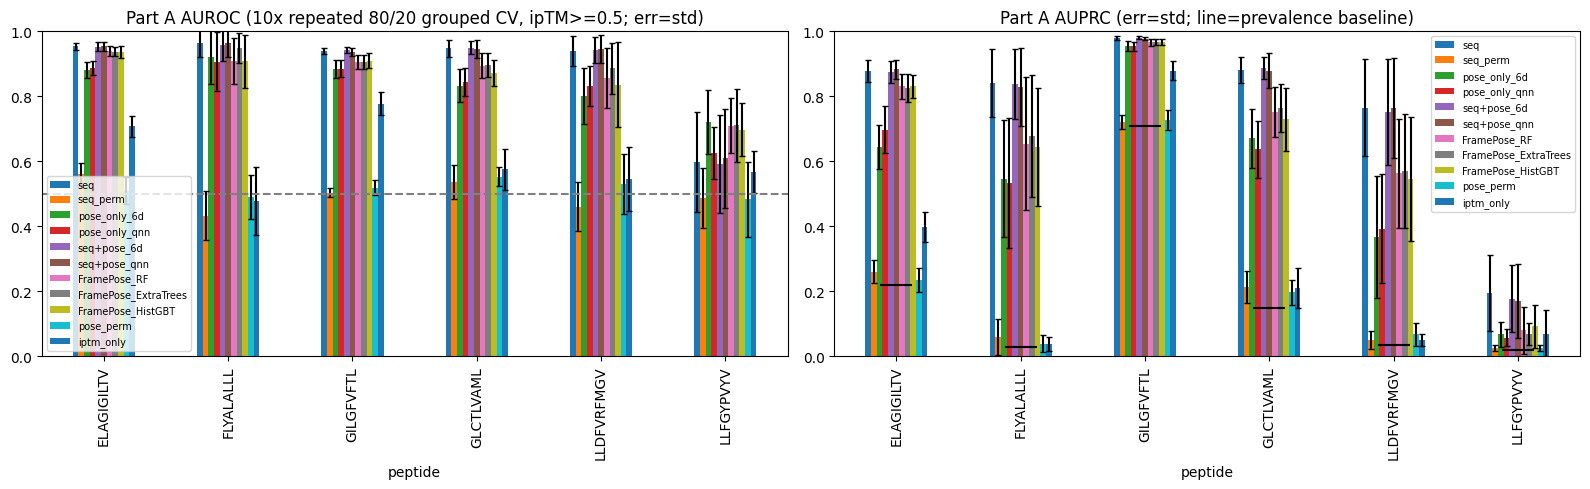

Part A mean+/-std (AUROC):
model                   seq         seq_perm     pose_only_6d    pose_only_qnn      seq+pose_6d     seq+pose_qnn     FramePose_RF FramePose_ExtraTrees FramePose_HistGBT        pose_perm        iptm_only
peptide                                                                                                                                                                                                   
ELAGIGILTV  0.953 +/- 0.012   0.56 +/- 0.036  0.881 +/- 0.024  0.888 +/- 0.022  0.952 +/- 0.013  0.953 +/- 0.013  0.938 +/- 0.015      0.938 +/- 0.015   0.935 +/- 0.018  0.509 +/- 0.043  0.707 +/- 0.032
FLYALALLL   0.964 +/- 0.044  0.432 +/- 0.076  0.922 +/- 0.086  0.907 +/- 0.092  0.958 +/- 0.048  0.963 +/- 0.043   0.908 +/- 0.07      0.948 +/- 0.046   0.908 +/- 0.081   0.49 +/- 0.068  0.478 +/- 0.105
GILGFVFTL     0.94 +/- 0.01  0.503 +/- 0.014  0.884 +/- 0.027  0.885 +/- 0.026   0.943 +/- 0.01  0.937 +/- 0.012  0.905 +/- 0.022      0.906 +/- 0.022    0.91 +/

In [11]:
import matplotlib.pyplot as plt
orderA=["seq","seq_perm","pose_only_6d","pose_only_qnn","seq+pose_6d","seq+pose_qnn",
        "FramePose_RF","FramePose_ExtraTrees","FramePose_HistGBT","pose_perm","iptm_only"]
cols=[m for m in orderA if m in set(resA.model)]
pa=resA.pivot_table(index="peptide",columns="model",values="auroc")[cols]
sa=resA.pivot_table(index="peptide",columns="model",values="auroc_sd")[cols]
pp=resA.pivot_table(index="peptide",columns="model",values="auprc")[cols]
sp=resA.pivot_table(index="peptide",columns="model",values="auprc_sd")[cols]
fig,ax=plt.subplots(1,2,figsize=(16,5))
pa.plot.bar(ax=ax[0],yerr=sa,capsize=2); ax[0].set_title("Part A AUROC (10x repeated 80/20 grouped CV, ipTM>=0.5; err=std)")
ax[0].set_ylim(0,1); ax[0].axhline(0.5,ls="--",c="gray"); ax[0].legend(fontsize=7)
pp.plot.bar(ax=ax[1],yerr=sp,capsize=2); ax[1].set_title("Part A AUPRC (err=std; line=prevalence baseline)"); ax[1].set_ylim(0,1); ax[1].legend(fontsize=7)
prevp=resA.groupby("peptide").prevalence.first().reindex(pp.index)
ax[1].scatter(np.arange(len(pp.index)),prevp.values,marker="_",s=500,c="black",zorder=6)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/partA.png",dpi=150); plt.show()
# Part A per-peptide table with std
print("Part A mean+/-std (AUROC):")
print((pa.round(3).astype(str)+" +/- "+sa.round(3).astype(str)).to_string())
print("\nPart A bootstrap:\n",bA.to_string(index=False))

## Part B — across peptide (peptide tower)
LOPO (unseen peptide) and MIXED (10× repeated leakage-controlled 80/20, novel TCR), with mismatch negatives. Paired bootstrap on MIXED pooled OOF: (seq+pep+pose) − (seq+pep).

**Note:** mismatch negatives are OFF by default (`USE_MISMATCH=False`) so the pose-discrimination comparison uses only posed examples — no null-pose/label confound. All negatives here are real, structured within-peptide non-binders.

In [14]:
AFS={"seq+pep":lambda:warm_start(PeptideAwareFusion(pose_vae=None)),
     "cond_pose_qnn":lambda:warm_start(CondPeptideAware(rotation_encoder='qnn')),
     "cond_pose_6d":lambda:warm_start(CondPeptideAware(rotation_encoder='6d')),
     "seq+pep+pose_qnn":lambda:warm_start(PeptideAwareFusion(pose_vae=vaeq)),
     "seq+pep+pose_6d":lambda:warm_start(PeptideAwareFusion(pose_vae=vae6)),
     "seq+pep+cond_pose_qnn":lambda:warm_start(CondPeptideAwareFusion(rotation_encoder='qnn')),
     "seq+pep+cond_pose_6d":lambda:warm_start(CondPeptideAwareFusion(rotation_encoder='6d')),
     }
AUXSET={"seq+pep+cond_pose_qnn"}   # trained with classification + reconstruction + KL
rowsB=[]

# MIXED: 10x repeated leakage-controlled 80/20
n=len(pool); groups=cluster_tcrs(pool); yM=pool.label.to_numpy().astype(int); prevM=round(float(yM.mean()),4)
splits=repeated_splits(pool); oofs={}
for name,fac in AFS.items():
    _,Pc,IDX,aucs,prcs=run_repeated(fac,pool,splits,augment=USE_MISMATCH,aux=(name in AUXSET))
    pagg,tested=aggregate_oof(IDX,Pc,n); oofs[name]=(pagg,tested)
    for i,(a,pr) in enumerate(zip(aucs,prcs)):
        rowsB.append({"regime":"MIXED","split":f"rep{i}","model":name,"prevalence":prevM,"auroc":round(float(a),4),"auprc":round(float(pr),4)})
    print(f"  MIXED {name:18s} AUROC={aucs.mean():.3f}+/-{aucs.std():.3f} AUPRC={prcs.mean():.3f}+/-{prcs.std():.3f} (prev={prevM})")

for cn,(a,b) in {"(seq+pep+pose_qnn)-(seq+pep)":("seq+pep+pose_qnn","seq+pep"),
                 "(seq+pep+cond_pose_qnn)-(seq+pep)":("seq+pep+cond_pose_qnn","seq+pep"),
                 "(seq+pep+cond_pose_qnn)-(seq+pep+pose_qnn)":("seq+pep+cond_pose_qnn","seq+pep+pose_qnn")}.items():
    ta=oofs[a][1]&oofs[b][1]
    (dR,loR,hiR,pR),(dP,loP,hiP,pP)=cluster_bootstrap(yM,oofs[a][0],oofs[b][0],groups,ta)
    print(f"  [{cn}] dAUROC={dR:+.3f} CI[{loR:+.3f},{hiR:+.3f}]  dAUPRC={dP:+.3f} CI[{loP:+.3f},{hiP:+.3f}]")

# LOPO (unseen peptide)
PEPTIDES=sorted(pool.peptide.unique())
for held in PEPTIDES:
    te=pool[pool.peptide==held]; tr=pool[pool.peptide!=held]
    if min((te.label==1).sum(),(te.label==0).sum())<3: continue
    trf=(add_mismatch(tr) if USE_MISMATCH else tr); prevH=round(float(te.label.mean()),4)
    for name,fac in AFS.items():
        model=fac().to(device)
        tl=DataLoader(PairData(trf.reset_index(drop=True)),batch_size=64,shuffle=True)
        vl=DataLoader(PairData(te.reset_index(drop=True)),batch_size=128)
        yt=trf.label.to_numpy().astype(int); pw=(yt==0).sum()/max((yt==1).sum(),1)
        (train_one_aux if name in AUXSET else train_one)(model,tl,15,1e-3,pw); pr,yy=predict(model,vl)
        rowsB.append({"regime":"LOPO","split":held,"model":name,"prevalence":prevH,
                      "auroc":round(roc_auc_score(yy,pr),4),"auprc":round(average_precision_score(yy,pr),4)})
        print(f"  LOPO {held:11s} {name:18s} AUROC={roc_auc_score(yy,pr):.3f}")

resB=pd.DataFrame(rowsB); resB.to_csv(f"{OUT_DIR}/partB_across.csv",index=False); resB

  MIXED seq+pep            AUROC=0.965+/-0.005 AUPRC=0.940+/-0.014 (prev=0.2816)
  MIXED cond_pose_qnn      AUROC=0.956+/-0.007 AUPRC=0.918+/-0.017 (prev=0.2816)
  MIXED cond_pose_6d       AUROC=0.957+/-0.008 AUPRC=0.918+/-0.018 (prev=0.2816)
  MIXED seq+pep+pose_qnn   AUROC=0.963+/-0.007 AUPRC=0.932+/-0.016 (prev=0.2816)
  MIXED seq+pep+pose_6d    AUROC=0.960+/-0.007 AUPRC=0.932+/-0.012 (prev=0.2816)
  MIXED seq+pep+cond_pose_qnn AUROC=0.959+/-0.009 AUPRC=0.933+/-0.015 (prev=0.2816)
  MIXED seq+pep+cond_pose_6d AUROC=0.961+/-0.008 AUPRC=0.935+/-0.015 (prev=0.2816)
  [(seq+pep+pose_qnn)-(seq+pep)] dAUROC=-0.004 CI[-0.007,-0.000]  dAUPRC=-0.011 CI[-0.018,-0.005]
  [(seq+pep+cond_pose_qnn)-(seq+pep)] dAUROC=-0.005 CI[-0.009,-0.002]  dAUPRC=-0.007 CI[-0.012,-0.003]
  [(seq+pep+cond_pose_qnn)-(seq+pep+pose_qnn)] dAUROC=-0.002 CI[-0.005,+0.002]  dAUPRC=+0.004 CI[-0.003,+0.010]
  LOPO ELAGIGILTV  seq+pep            AUROC=0.525
  LOPO ELAGIGILTV  cond_pose_qnn      AUROC=0.744
  LOPO ELAGIGIL

,regime,split,model,prevalence,auroc,auprc
0,MIXED,rep0,seq+pep,0.2816,0.9587,0.9286
1,MIXED,rep1,seq+pep,0.2816,0.9630,0.9327
2,MIXED,rep2,seq+pep,0.2816,0.9638,0.9419
3,MIXED,rep3,seq+pep,0.2816,0.9680,0.9471
4,MIXED,rep4,seq+pep,0.2816,0.9771,0.9644
...,...,...,...,...,...,...
107,LOPO,LLFGYPVYV,cond_pose_6d,0.0182,0.7351,0.0539
108,LOPO,LLFGYPVYV,seq+pep+pose_qnn,0.0182,0.5321,0.0886
109,LOPO,LLFGYPVYV,seq+pep+pose_6d,0.0182,0.5890,0.2158
110,LOPO,LLFGYPVYV,seq+pep+cond_pose_qnn,0.0182,0.5808,0.1626


## Results + plots


Part B mean +/- std:
                               auroc         auprc       
                               mean    std   mean    std
regime model                                            
LOPO   cond_pose_6d           0.495  0.187  0.178  0.202
       cond_pose_qnn          0.566  0.179  0.217  0.236
       seq+pep                0.511  0.087  0.213  0.222
       seq+pep+cond_pose_6d   0.457  0.122  0.189  0.211
       seq+pep+cond_pose_qnn  0.467  0.110  0.193  0.206
       seq+pep+pose_6d        0.434  0.138  0.206  0.206
       seq+pep+pose_qnn       0.492  0.140  0.190  0.203
MIXED  cond_pose_6d           0.957  0.009  0.918  0.019
       cond_pose_qnn          0.956  0.007  0.918  0.018
       seq+pep                0.965  0.006  0.940  0.015
       seq+pep+cond_pose_6d   0.961  0.008  0.935  0.015
       seq+pep+cond_pose_qnn  0.959  0.010  0.933  0.016
       seq+pep+pose_6d        0.960  0.007  0.932  0.012
       seq+pep+pose_qnn       0.963  0.007  0.932  0.017


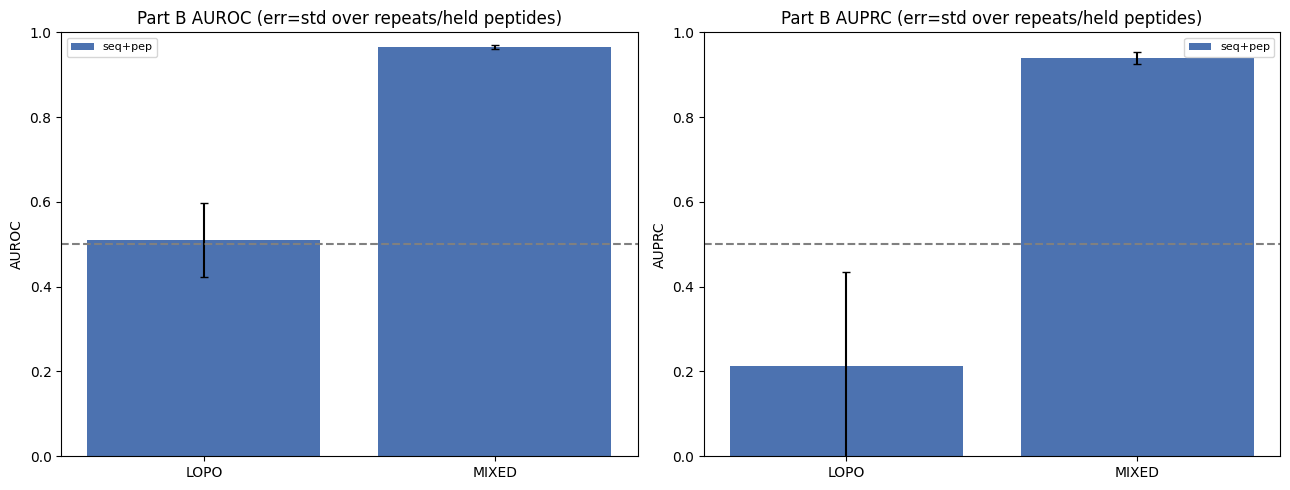

saved tables + figures to /content/drive/MyDrive/tcrpmhc_outputs


In [15]:
# Part B mean +/- std (LOPO std across held peptides; MIXED std across repeats)
summB=resB.groupby(["regime","model"])[["auroc","auprc"]].agg(["mean","std"])
print("\nPart B mean +/- std:\n",summB.round(3))
# ---- Part B figure: 3 arms x {LOPO, MIXED}, AUROC & AUPRC, std error bars ----
orderB=["seq+pep","seq+pep+pose","seq+pep+cond_pose"]
orderB=[m for m in orderB if m in set(resB.model)]
regimes=[r for r in ["LOPO","MIXED"] if r in set(resB.regime)]
colB={"seq+pep":"#4C72B0","seq+pep+pose":"#C44E52","seq+pep+cond_pose":"#2a9d8f"}
xb=np.arange(len(regimes)); wb=0.8/max(len(orderB),1)
figB,axB=plt.subplots(1,2,figsize=(13,5))
for j,metric in enumerate(["auroc","auprc"]):
    for i,mdl in enumerate(orderB):
        mean=[summB.loc[(r,mdl),(metric,"mean")] if (r,mdl) in summB.index else np.nan for r in regimes]
        sd=[summB.loc[(r,mdl),(metric,"std")] if (r,mdl) in summB.index else 0 for r in regimes]
        axB[j].bar(xb+(i-(len(orderB)-1)/2)*wb,mean,wb,yerr=sd,capsize=3,label=mdl,color=colB.get(mdl))
    axB[j].set_xticks(xb); axB[j].set_xticklabels(regimes); axB[j].set_ylim(0,1)
    axB[j].axhline(0.5,ls="--",c="gray"); axB[j].set_ylabel(metric.upper())
    axB[j].set_title("Part B "+metric.upper()+" (err=std over repeats/held peptides)"); axB[j].legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/partB.png",dpi=150); plt.show()
print("saved tables + figures to", OUT_DIR)